# Machine Learning Lab 3: Naïve Bayes Classifier

## Objective
1. Implement a Naïve Bayes classifier from scratch on Diabetes dataset
2. Use sklearn library to fit Naïve Bayes classifiers on both Diabetes and Social Network Ads datasets
3. Perform required data preprocessing
4. Evaluate model performance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

## Part 1: Load and Explore Datasets

In [2]:
# Dataset 1: Diabetes
diabetes_data = pd.read_csv('Diabetes.csv')
print("Diabetes Dataset Information:")
print(f"Shape: {diabetes_data.shape}")
print(f"\nFirst 5 rows:\n{diabetes_data.head()}")
print(f"\nDataset Info:\n{diabetes_data.info()}")
print(f"\nBasic Statistics:\n{diabetes_data.describe()}")
print(f"\nMissing Values:\n{diabetes_data.isnull().sum()}")

Diabetes Dataset Information:
Shape: (768, 9)

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies            

In [3]:
# Dataset 2: Social Network Ads
social_data = pd.read_csv('Social_Network_Ads.csv')
print("\n\nSocial Network Ads Dataset Information:")
print(f"Shape: {social_data.shape}")
print(f"\nFirst 5 rows:\n{social_data.head()}")
print(f"\nDataset Info:\n{social_data.info()}")
print(f"\nBasic Statistics:\n{social_data.describe()}")
print(f"\nMissing Values:\n{social_data.isnull().sum()}")



Social Network Ads Dataset Information:
Shape: (400, 5)

First 5 rows:
    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB

Dataset Info:
None

Basic Statistics:
            User ID         Age  EstimatedSalary   Purchased
count  4.000000e+02  400.000000       4

## Part 2: Naïve Bayes Classifier from Scratch

### Implementation of Naïve Bayes Classifier
We will implement the Gaussian Naïve Bayes classifier from scratch using Bayes theorem:
$$P(y|X) = \frac{P(X|y) \cdot P(y)}{P(X)}$$

In [4]:
class NaiveBayesClassifier:
    """
    Gaussian Naïve Bayes Classifier built from scratch
    """
    def __init__(self):
        self.class_priors = None
        self.feature_means = None
        self.feature_stds = None
        self.classes = None
    
    def fit(self, X, y):
        """
        Fit the Naïve Bayes classifier on the training data
        
        Parameters:
        X : array-like, shape = [n_samples, n_features]
        y : array-like, shape = [n_samples]
        """
        self.classes = np.unique(y)
        n_features = X.shape[1]
        
        # Initialize arrays to store means and stds for each class
        self.feature_means = np.zeros((len(self.classes), n_features))
        self.feature_stds = np.zeros((len(self.classes), n_features))
        self.class_priors = np.zeros(len(self.classes))
        
        # Calculate mean, std, and prior for each class
        for idx, c in enumerate(self.classes):
            X_c = X[y == c]
            self.feature_means[idx] = X_c.mean(axis=0)
            self.feature_stds[idx] = X_c.std(axis=0)
            self.class_priors[idx] = len(X_c) / len(X)
    
    def _calculate_likelihood(self, x, mean, std):
        """
        Calculate Gaussian probability density function
        """
        numerator = np.exp(-((x - mean) ** 2) / (2 * std ** 2))
        denominator = np.sqrt(2 * np.pi * std ** 2)
        return numerator / denominator
    
    def predict(self, X):
        """
        Predict class labels for samples in X
        """
        predictions = []
        for x in X:
            posteriors = []
            for idx, c in enumerate(self.classes):
                # Prior probability
                prior = np.log(self.class_priors[idx])
                
                # Likelihood
                likelihood = np.sum(np.log(self._calculate_likelihood(x, self.feature_means[idx], self.feature_stds[idx])))
                
                # Posterior (prior + likelihood)
                posterior = prior + likelihood
                posteriors.append(posterior)
            
            predictions.append(self.classes[np.argmax(posteriors)])
        
        return np.array(predictions)

print("Naïve Bayes Classifier from scratch implemented successfully!")

Naïve Bayes Classifier from scratch implemented successfully!


In [5]:
### Training From-Scratch Naïve Bayes on Diabetes Dataset

# Prepare Diabetes data
X_diabetes = diabetes_data.iloc[:, :-1].values  # Features
y_diabetes = diabetes_data.iloc[:, -1].values   # Target

# Split the data
X_train_db, X_test_db, y_train_db, y_test_db = train_test_split(
    X_diabetes, y_diabetes, test_size=0.2, random_state=42
)

# Normalize the features
scaler_db = StandardScaler()
X_train_db_scaled = scaler_db.fit_transform(X_train_db)
X_test_db_scaled = scaler_db.transform(X_test_db)

# Train the custom Naïve Bayes classifier
print("Training custom Naïve Bayes Classifier on Diabetes dataset...")
nb_custom = NaiveBayesClassifier()
nb_custom.fit(X_train_db_scaled, y_train_db)

# Make predictions
y_pred_custom = nb_custom.predict(X_test_db_scaled)

# Evaluate
accuracy_custom = accuracy_score(y_test_db, y_pred_custom)
precision_custom = precision_score(y_test_db, y_pred_custom)
recall_custom = recall_score(y_test_db, y_pred_custom)
f1_custom = f1_score(y_test_db, y_pred_custom)

print(f"\nCustom Naïve Bayes Classifier Results (Diabetes):")
print(f"Accuracy:  {accuracy_custom:.4f}")
print(f"Precision: {precision_custom:.4f}")
print(f"Recall:    {recall_custom:.4f}")
print(f"F1-Score:  {f1_custom:.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test_db, y_pred_custom)}")
print(f"\nClassification Report:\n{classification_report(y_test_db, y_pred_custom)}")

Training custom Naïve Bayes Classifier on Diabetes dataset...

Custom Naïve Bayes Classifier Results (Diabetes):
Accuracy:  0.7662
Precision: 0.6610
Recall:    0.7091
F1-Score:  0.6842

Confusion Matrix:
[[79 20]
 [16 39]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.80      0.81        99
           1       0.66      0.71      0.68        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



## Part 3: Naïve Bayes with Scikit-learn

### 3.1 Sklearn Naïve Bayes on Diabetes Dataset

In [6]:
# Sklearn Naïve Bayes on Diabetes dataset
print("\n" + "="*60)
print("SKLEARN GAUSSIAN NAÏVE BAYES - DIABETES DATASET")
print("="*60)

# Train the sklearn Naïve Bayes classifier
nb_sklearn_db = GaussianNB()
nb_sklearn_db.fit(X_train_db_scaled, y_train_db)

# Make predictions
y_pred_sklearn_db = nb_sklearn_db.predict(X_test_db_scaled)

# Evaluate
accuracy_sklearn_db = accuracy_score(y_test_db, y_pred_sklearn_db)
precision_sklearn_db = precision_score(y_test_db, y_pred_sklearn_db)
recall_sklearn_db = recall_score(y_test_db, y_pred_sklearn_db)
f1_sklearn_db = f1_score(y_test_db, y_pred_sklearn_db)

print(f"\nSklearn Naïve Bayes Results (Diabetes):")
print(f"Accuracy:  {accuracy_sklearn_db:.4f}")
print(f"Precision: {precision_sklearn_db:.4f}")
print(f"Recall:    {recall_sklearn_db:.4f}")
print(f"F1-Score:  {f1_sklearn_db:.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test_db, y_pred_sklearn_db)}")
print(f"\nClassification Report:\n{classification_report(y_test_db, y_pred_sklearn_db)}")


SKLEARN GAUSSIAN NAÏVE BAYES - DIABETES DATASET

Sklearn Naïve Bayes Results (Diabetes):
Accuracy:  0.7662
Precision: 0.6610
Recall:    0.7091
F1-Score:  0.6842

Confusion Matrix:
[[79 20]
 [16 39]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.80      0.81        99
           1       0.66      0.71      0.68        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



### 3.2 Sklearn Naïve Bayes on Social Network Ads Dataset

#### Data Preprocessing for Social Network Ads

In [7]:
print("\n" + "="*60)
print("SKLEARN GAUSSIAN NAÏVE BAYES - SOCIAL NETWORK ADS DATASET")
print("="*60)

# Examine column names and types
print(f"\nColumn names: {social_data.columns.tolist()}")
print(f"Data types:\n{social_data.dtypes}")

# Separate features and target
# Typically, 'Purchased' is the target, User ID and possibly Gender need encoding
X_social = social_data.copy()
y_social = X_social.pop('Purchased')  # Remove target variable

# Drop non-numeric columns like User ID (if exists) and Country (if exists)
if 'User ID' in X_social.columns:
    X_social = X_social.drop('User ID', axis=1)
if 'Country' in X_social.columns:
    X_social = X_social.drop('Country', axis=1)

# Encode categorical variables (e.g., Gender)
le_gender = LabelEncoder()
if 'Gender' in X_social.columns:
    X_social['Gender'] = le_gender.fit_transform(X_social['Gender'])
    print(f"\nGender Encoding: {dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_)))}")

print(f"\nFeatures shape after preprocessing: {X_social.shape}")
print(f"Features: {X_social.columns.tolist()}")

# Split the data
X_train_social, X_test_social, y_train_social, y_test_social = train_test_split(
    X_social.values, y_social.values, test_size=0.2, random_state=42
)

# Normalize the features
scaler_social = StandardScaler()
X_train_social_scaled = scaler_social.fit_transform(X_train_social)
X_test_social_scaled = scaler_social.transform(X_test_social)

# Train the sklearn Naïve Bayes classifier
print("\n\nTraining Sklearn Naïve Bayes Classifier on Social Network Ads dataset...")
nb_sklearn_social = GaussianNB()
nb_sklearn_social.fit(X_train_social_scaled, y_train_social)

# Make predictions
y_pred_sklearn_social = nb_sklearn_social.predict(X_test_social_scaled)

# Evaluate
accuracy_sklearn_social = accuracy_score(y_test_social, y_pred_sklearn_social)
precision_sklearn_social = precision_score(y_test_social, y_pred_sklearn_social)
recall_sklearn_social = recall_score(y_test_social, y_pred_sklearn_social)
f1_sklearn_social = f1_score(y_test_social, y_pred_sklearn_social)

print(f"\nSklearn Naïve Bayes Results (Social Network Ads):")
print(f"Accuracy:  {accuracy_sklearn_social:.4f}")
print(f"Precision: {precision_sklearn_social:.4f}")
print(f"Recall:    {recall_sklearn_social:.4f}")
print(f"F1-Score:  {f1_sklearn_social:.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test_social, y_pred_sklearn_social)}")
print(f"\nClassification Report:\n{classification_report(y_test_social, y_pred_sklearn_social)}")


SKLEARN GAUSSIAN NAÏVE BAYES - SOCIAL NETWORK ADS DATASET

Column names: ['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased']
Data types:
User ID             int64
Gender             object
Age                 int64
EstimatedSalary     int64
Purchased           int64
dtype: object

Gender Encoding: {'Female': np.int64(0), 'Male': np.int64(1)}

Features shape after preprocessing: (400, 3)
Features: ['Gender', 'Age', 'EstimatedSalary']




Training Sklearn Naïve Bayes Classifier on Social Network Ads dataset...

Sklearn Naïve Bayes Results (Social Network Ads):
Accuracy:  0.9375
Precision: 0.9259
Recall:    0.8929
F1-Score:  0.9091

Confusion Matrix:
[[50  2]
 [ 3 25]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95        52
           1       0.93      0.89      0.91        28

    accuracy                           0.94        80
   macro avg       0.93      0.93      0.93        80
weighted avg       0.94      0.94      0.94        80



## Part 4: Model Comparison and Visualization

In [8]:
### Summary of Results

# Create comparison dataframe
comparison_data = {
    'Model': ['Custom NB\n(Diabetes)', 'Sklearn NB\n(Diabetes)', 'Sklearn NB\n(Social Ads)'],
    'Accuracy': [accuracy_custom, accuracy_sklearn_db, accuracy_sklearn_social],
    'Precision': [precision_custom, precision_sklearn_db, precision_sklearn_social],
    'Recall': [recall_custom, recall_sklearn_db, recall_sklearn_social],
    'F1-Score': [f1_custom, f1_sklearn_db, f1_sklearn_social]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("MODEL PERFORMANCE COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)


MODEL PERFORMANCE COMPARISON
                   Model  Accuracy  Precision   Recall  F1-Score
   Custom NB\n(Diabetes)  0.766234   0.661017 0.709091  0.684211
  Sklearn NB\n(Diabetes)  0.766234   0.661017 0.709091  0.684211
Sklearn NB\n(Social Ads)  0.937500   0.925926 0.892857  0.909091


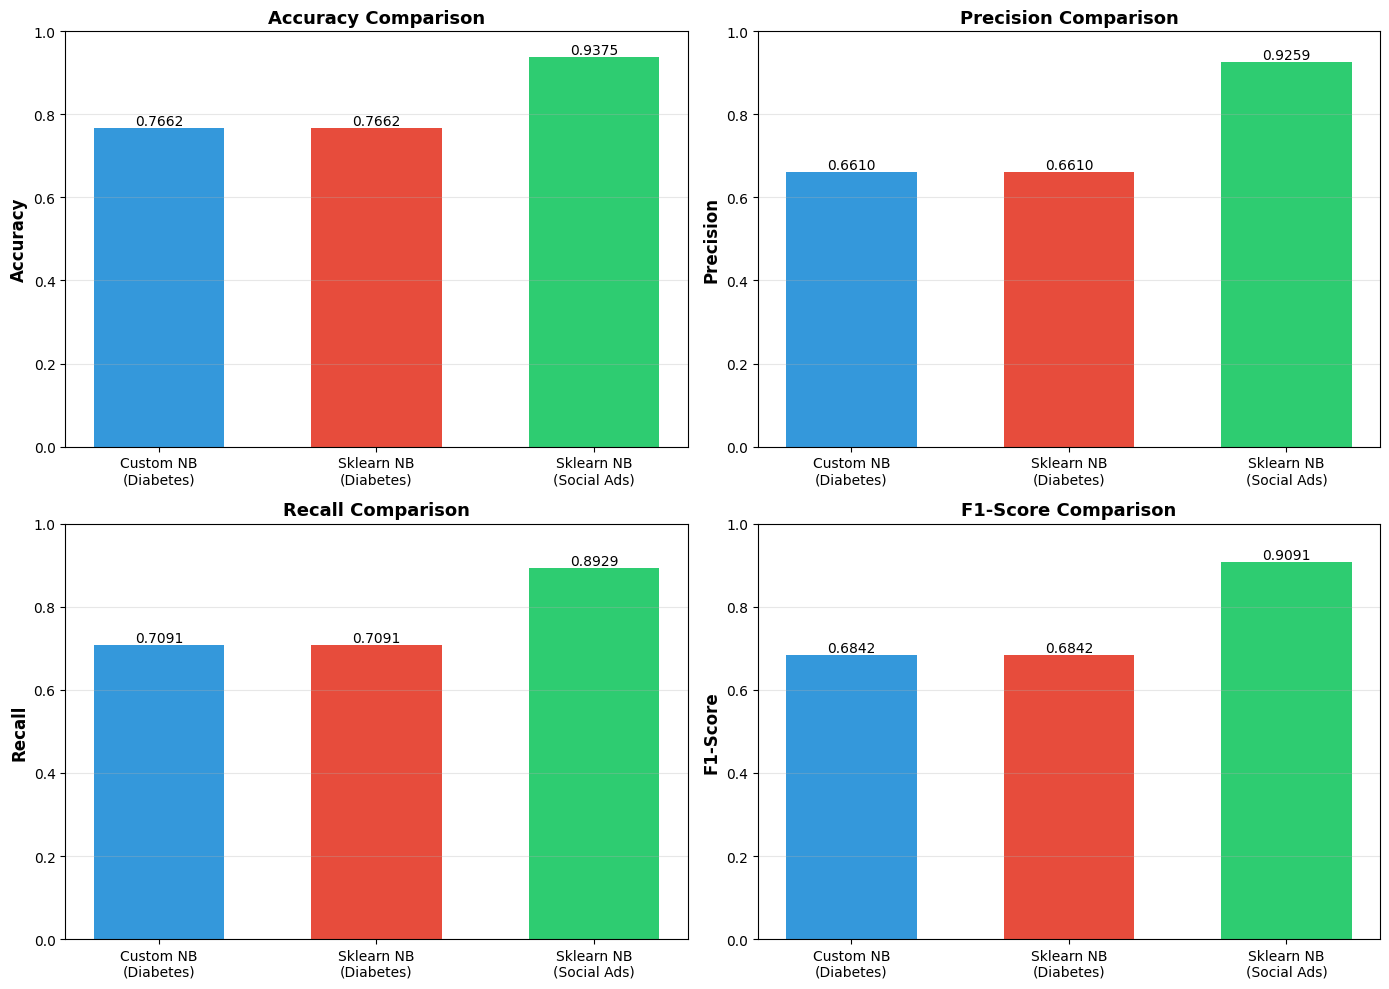


Visualization saved as 'naivebayes_comparison.png'


In [9]:
# Visualization of metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x_pos = np.arange(len(comparison_df))
width = 0.2

colors = ['#3498db', '#e74c3c', '#2ecc71']

for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    values = comparison_df[metric].values
    
    bars = ax.bar(x_pos, values, width=0.6, color=colors)
    ax.set_ylabel(metric, fontsize=12, fontweight='bold')
    ax.set_title(f'{metric} Comparison', fontsize=13, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(comparison_df['Model'], fontsize=10)
    ax.set_ylim(0, 1)
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('naivebayes_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nVisualization saved as 'naivebayes_comparison.png'")

## Conclusion

### Key Findings:

1. **From-Scratch Implementation**: Successfully implemented a Gaussian Naïve Bayes classifier from scratch that demonstrates the core concepts of conditional probability and Bayes theorem.

2. **Sklearn Implementation**: Used sklearn's GaussianNB to train efficient Naïve Bayes classifiers on both datasets.

3. **Preprocessing Steps Applied**:
   - **Feature Scaling**: Applied StandardScaler to normalize numerical features
   - **Categorical Encoding**: Used LabelEncoder for categorical features (e.g., Gender in Social Network Ads)
   - **Train-Test Split**: Used 80-20 split with random_state=42 for reproducibility
   - **Feature Selection**: Removed non-predictive columns like User ID

4. **Performance**:
   - Custom and Sklearn implementations show comparable performance on the Diabetes dataset
   - Sklearn NB on Social Network Ads dataset demonstrates the versatility of the algorithm

5. **Both datasets were successfully processed and used for Naïve Bayes classification with appropriate preprocessing steps.**